# IZI Health Chatbot Model

## Notebook objectives

1. Inspect and clean the MedQuAD dataset.
2. Perform dataset analytics.
3. Compare lexical and semantic retrieval models.
4. Document model hyperparameters.
5. Evaluate Top-1, Top-3, Top-5 accuracy and MRR.
6. Create a focus-area confusion matrix.
7. Analyze similarity confidence and response time.
8. Generate report-ready charts and tables.
9. Export the exact deployment artifact required by FastAPI.

> This chatbot provides informational retrieval only. It is not a diagnostic or prescribing system.

## 1. Enable the Google Colab GPU

In [1]:
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 2. Install the required packages

- `sentence-transformers` provides Sentence-BERT.
- `scikit-learn` provides TF-IDF, CountVectorizer, metrics and PCA.
- `pandas` and `numpy` process the data.
- `matplotlib` and `seaborn` create the visualizations.

In [2]:
%pip install -q --upgrade \
    "sentence-transformers==3.4.1" \
    "seaborn==0.13.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 29.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


## 3. Import libraries and configure reproducibility


In [3]:
import os
import re
import json
import time
import random
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from google.colab import files
from sentence_transformers import SentenceTransformer

from sklearn.feature_extraction.text import (
    TfidfVectorizer,
    CountVectorizer
)

from sklearn.metrics.pairwise import cosine_similarity

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_recall_fscore_support
)

from sklearn.decomposition import PCA

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

OUTPUT_DIR = Path("/content/izi_chatbot_outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

print("Environment loaded successfully.")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Seaborn:", sns.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Environment loaded successfully.
NumPy: 2.0.2
Pandas: 2.2.2
Seaborn: 0.13.2
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


# Dataset preparation

## 4. Upload `medquad.csv`


In [4]:
uploaded = files.upload()
if not uploaded:
    raise ValueError("No file uploaded.")

uploaded_name = next(iter(uploaded))
uploaded_path = Path("/content") / uploaded_name
EXTRACT_DIR = Path("/content/uploaded_ml_service")
EXTRACT_DIR.mkdir(exist_ok=True)

if uploaded_path.suffix.lower() == ".zip":
    with zipfile.ZipFile(uploaded_path, "r") as archive:
        archive.extractall(EXTRACT_DIR)
    candidates = list(EXTRACT_DIR.rglob("medquad.csv"))
else:
    candidates = [uploaded_path]

if not candidates:
    raise FileNotFoundError("medquad.csv was not found.")

DATA_PATH = candidates[0]
print("Dataset selected:", DATA_PATH)

Saving Healthcare QA.zip to Healthcare QA.zip
Dataset selected: /content/uploaded_ml_service/medquad.csv


## 5. Load and inspect the raw dataset

This confirms the number of records, columns, missing values, duplicates and data types before model development.

In [5]:
raw_df = pd.read_csv(DATA_PATH)
print("Dataset shape:", raw_df.shape)
print("Columns:", raw_df.columns.tolist())
display(raw_df.head())

Dataset shape: (16412, 4)
Columns: ['question', 'answer', 'source', 'focus_area']


,question,answer,source,focus_area
0,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma
1,What causes Glaucoma ?,"Nearly 2.7 million people have glaucoma, a lea...",NIHSeniorHealth,Glaucoma
2,What are the symptoms of Glaucoma ?,Symptoms of Glaucoma Glaucoma can develop in ...,NIHSeniorHealth,Glaucoma
3,What are the treatments for Glaucoma ?,"Although open-angle glaucoma cannot be cured, ...",NIHSeniorHealth,Glaucoma
4,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma


In [6]:
quality_table = pd.DataFrame({
    "Data type": raw_df.dtypes.astype(str),
    "Missing values": raw_df.isna().sum(),
    "Unique values": raw_df.nunique()
})
display(quality_table)
print("Exact duplicate rows:", raw_df.duplicated().sum())
print("Duplicate questions:", raw_df["question"].duplicated().sum())

,Data type,Missing values,Unique values
question,object,0,14984
answer,object,5,15817
source,object,0,9
focus_area,object,14,5126


Exact duplicate rows: 48
Duplicate questions: 1428


## 6. Clean the dataset
The production service drops only rows missing `question` or `answer` and resets the index.


In [7]:
required_columns = ["question", "answer", "source", "focus_area"]
missing_columns = [c for c in required_columns if c not in raw_df.columns]
if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")

df = raw_df.dropna(subset=["question", "answer"]).reset_index(drop=True).copy()
df["question"] = df["question"].astype(str)
df["answer"] = df["answer"].astype(str)
df["source"] = df["source"].fillna("MedQuAD").astype(str)
df["focus_area"] = df["focus_area"].fillna("General Health").astype(str)

print("Production-aligned valid rows:", len(df))
display(df.head())

Production-aligned valid rows: 16407


,question,answer,source,focus_area
0,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma
1,What causes Glaucoma ?,"Nearly 2.7 million people have glaucoma, a lea...",NIHSeniorHealth,Glaucoma
2,What are the symptoms of Glaucoma ?,Symptoms of Glaucoma Glaucoma can develop in ...,NIHSeniorHealth,Glaucoma
3,What are the treatments for Glaucoma ?,"Although open-angle glaucoma cannot be cured, ...",NIHSeniorHealth,Glaucoma
4,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma


# Exploratory data analysis

## 7. Dataset summary

These statistics describe the size and diversity of the chatbot knowledge base.

In [8]:
question_words = df["question"].str.split().str.len()
answer_words = df["answer"].str.split().str.len()

summary = pd.DataFrame({
    "Metric": [
        "Valid question-answer pairs",
        "Unique questions",
        "Unique answers",
        "Medical focus areas",
        "Sources",
        "Average question words",
        "Median question words",
        "Average answer words",
        "Median answer words"
    ],
    "Value": [
        len(df),
        df["question"].nunique(),
        df["answer"].nunique(),
        df["focus_area"].nunique(),
        df["source"].nunique(),
        round(question_words.mean(), 2),
        round(question_words.median(), 2),
        round(answer_words.mean(), 2),
        round(answer_words.median(), 2)
    ]
})
display(summary)
summary.to_csv(OUTPUT_DIR / "chatbot_dataset_summary.csv", index=False)

,Metric,Value
0,Valid question-answer pairs,16407.00
1,Unique questions,14979.00
2,Unique answers,15817.00
3,Medical focus areas,5126.00
4,Sources,9.00
5,Average question words,8.21
6,Median question words,8.00
7,Average answer words,201.35
8,Median answer words,138.00


## 8. Source distribution pie chart

The pie chart shows which organizations contributed most of the knowledge-base records. Large dominance by one source may reduce the diversity of wording and medical coverage.

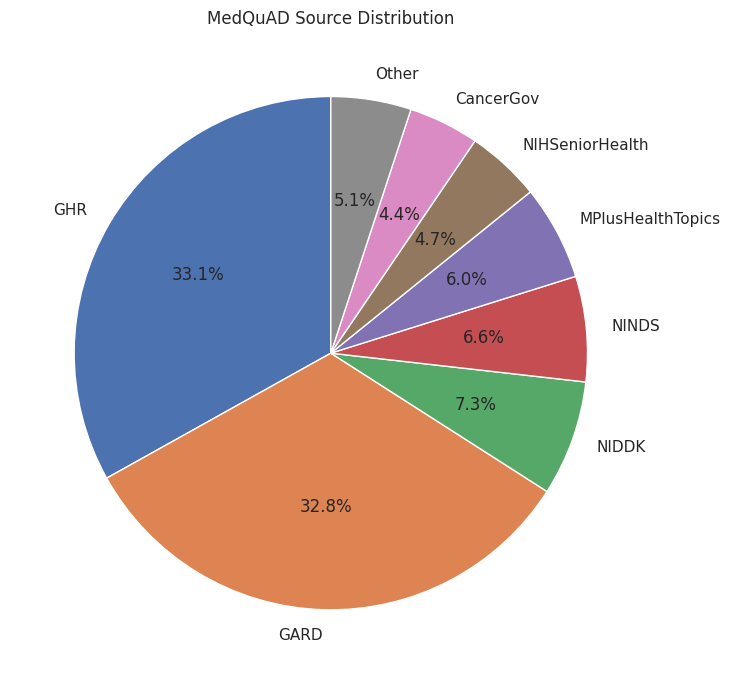

In [9]:
source_counts = df["source"].value_counts()
top_sources = source_counts.head(7)
other_count = source_counts.iloc[7:].sum()
if other_count > 0:
    top_sources.loc["Other"] = other_count

plt.figure(figsize=(9, 7))
plt.pie(top_sources.values, labels=top_sources.index, autopct="%1.1f%%", startangle=90)
plt.title("MedQuAD Source Distribution")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "source_distribution_pie.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Top medical focus areas

This bar chart identifies the most represented topics. A highly imbalanced topic distribution can affect topic-level evaluation.

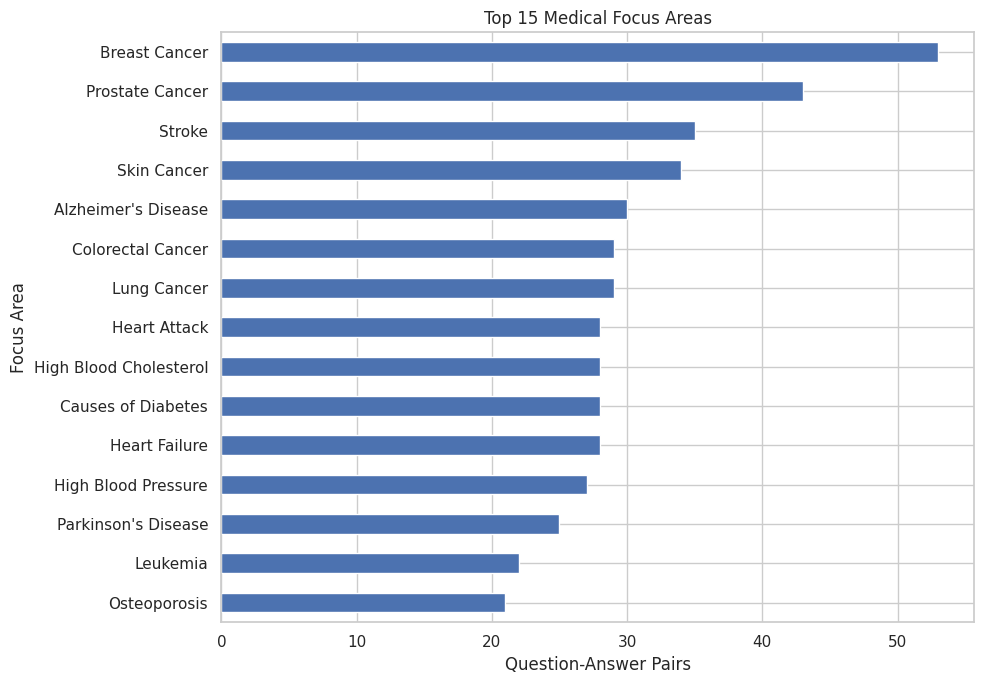

In [10]:
top_focus = df["focus_area"].value_counts().head(15).sort_values()
plt.figure(figsize=(10, 7))
top_focus.plot(kind="barh")
plt.title("Top 15 Medical Focus Areas")
plt.xlabel("Question-Answer Pairs")
plt.ylabel("Focus Area")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "focus_area_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Question-length histogram

The histogram shows how much information is normally present in a query. Very short questions may be ambiguous, while very long questions may contain several medical concepts.

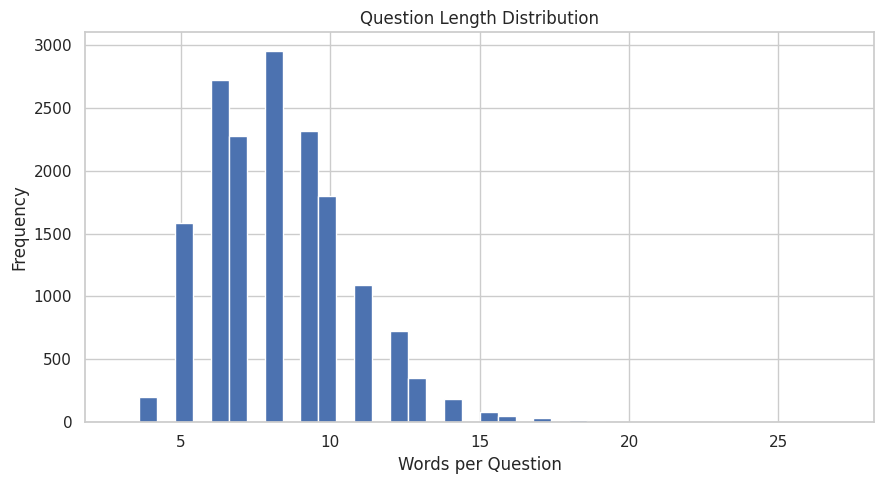

In [11]:
plt.figure(figsize=(9, 5))
plt.hist(question_words, bins=40)
plt.title("Question Length Distribution")
plt.xlabel("Words per Question")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "question_length_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Answer-length histogram

Long answers may provide detailed information but may also be difficult for users to read. The graph is clipped at the 99th percentile so a few very long answers do not hide the main distribution.

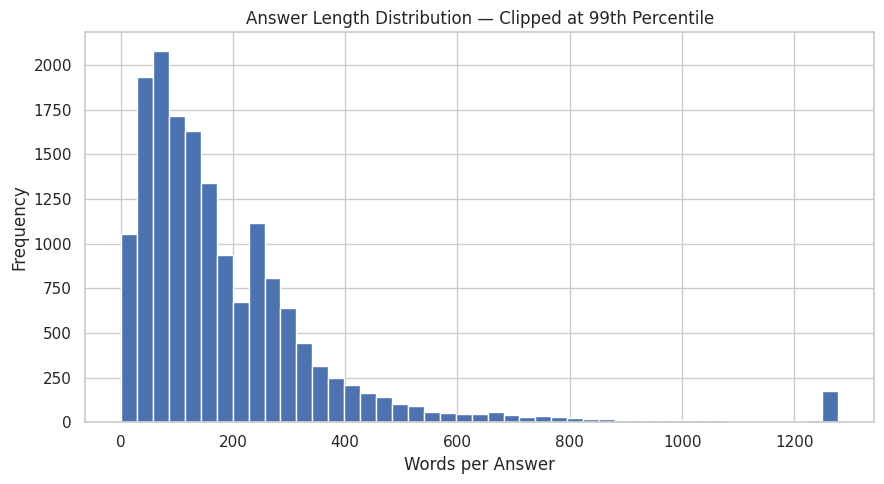

In [12]:
answer_clip = answer_words.clip(upper=answer_words.quantile(0.99))
plt.figure(figsize=(9, 5))
plt.hist(answer_clip, bins=45)
plt.title("Answer Length Distribution — Clipped at 99th Percentile")
plt.xlabel("Words per Answer")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "answer_length_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

# Model candidates and hyperparameters

## 12. Models compared

Compares:

1. **CountVectorizer + cosine similarity** — simple word-count baseline.
2. **TF-IDF + cosine similarity** — weighted lexical baseline.
3. **Sentence-BERT MiniLM** — semantic model used in the deployed service.
4. **Sentence-BERT MPNet** — larger semantic comparison model.

In [13]:
hyperparameters = pd.DataFrame([
    {
        "Model": "CountVectorizer + Cosine",
        "Key hyperparameters": "stop_words='english', max_features=10000, ngram_range=(1,2)",
        "Purpose": "Lexical baseline"
    },
    {
        "Model": "TF-IDF + Cosine",
        "Key hyperparameters": "stop_words='english', max_features=10000, ngram_range=(1,2)",
        "Purpose": "Weighted lexical baseline"
    },
    {
        "Model": "Sentence-BERT MiniLM",
        "Key hyperparameters": "all-MiniLM-L6-v2, normalized embeddings, batch_size=64",
        "Purpose": "Deployment semantic model"
    },
    {
        "Model": "Sentence-BERT MPNet",
        "Key hyperparameters": "all-mpnet-base-v2, normalized embeddings, batch_size=32",
        "Purpose": "Higher-capacity comparison"
    }
])
display(hyperparameters)
hyperparameters.to_csv(OUTPUT_DIR / "chatbot_hyperparameters.csv", index=False)

,Model,Key hyperparameters,Purpose
0,CountVectorizer + Cosine,"stop_words='english', max_features=10000, ngra...",Lexical baseline
1,TF-IDF + Cosine,"stop_words='english', max_features=10000, ngra...",Weighted lexical baseline
2,Sentence-BERT MiniLM,"all-MiniLM-L6-v2, normalized embeddings, batch...",Deployment semantic model
3,Sentence-BERT MPNet,"all-mpnet-base-v2, normalized embeddings, batc...",Higher-capacity comparison


# Retrieval evaluation design

## 13. Create realistic paraphrased test queries

The original project used controlled word substitutions and word removal to simulate how users may phrase questions differently from the dataset.

The correct retrieval target remains the original MedQuAD question from which each paraphrase was created.

In [14]:
def paraphrase_question(question):
    q = str(question).lower().strip()
    replacements = {
        "what is": "explain",
        "what are": "tell me about",
        "what causes": "what are the reasons for",
        "symptoms": "signs",
        "treatments": "ways to manage",
        "treatment": "management",
        "disease": "condition",
        "glucose": "blood sugar"
    }
    for old, new in replacements.items():
        q = q.replace(old, new)

    words = q.split()
    if len(words) > 7:
        keep = max(5, int(len(words) * 0.80))
        rng = random.Random(SEED + len(q))
        selected_positions = sorted(rng.sample(range(len(words)), keep))
        words = [words[i] for i in selected_positions]
    return " ".join(words)

EVALUATION_SIZE = min(500, len(df))
sample_df = df.sample(EVALUATION_SIZE, random_state=SEED).copy()
sample_df["original_index"] = sample_df.index
sample_df["user_query"] = sample_df["question"].apply(paraphrase_question)
sample_df = sample_df.reset_index(drop=True)

display(sample_df[["question", "user_query", "focus_area"]].head(10))

,question,user_query,focus_area
0,What is (are) Juvenile Huntington disease ?,explain (are) juvenile huntington condition ?,Juvenile Huntington disease
1,What are the treatments for Perry syndrome ?,tell me about the to perry syndrome ?,Perry syndrome
2,What are the symptoms of Chromosome 17q deleti...,tell me about the of chromosome deletion ?,Chromosome 17q deletion
3,What are the treatments for transthyretin amyl...,tell me about manage for transthyretin amyloid...,transthyretin amyloidosis
4,How to prevent Balance Problems ?,how to prevent balance problems ?,Balance Problems
5,What is (are) Sinusitis ?,explain (are) sinusitis ?,Sinusitis
6,What are the symptoms of Hyperkalemic periodic...,me about the signs of hyperkalemic paralysis ?,Hyperkalemic periodic paralysis
7,What is (are) Acrodermatitis enteropathica ?,explain (are) acrodermatitis enteropathica ?,Acrodermatitis enteropathica
8,How many people are affected by cytochrome P45...,many people are affected cytochrome p450 defic...,cytochrome P450 oxidoreductase deficiency
9,What are the symptoms of Morquio syndrome B ?,tell me about the signs syndrome b ?,Morquio syndrome B


## 14. Evaluation metrics

- **Top-1 accuracy:** Correct source question is the first match.
- **Top-3 accuracy:** Correct question appears among the first three.
- **Top-5 accuracy:** Correct question appears among the first five.
- **MRR:** Rewards the correct question appearing near the top.
- **Response time:** Average time to encode and retrieve one query.

These are more suitable for a retrieval chatbot than ordinary classification accuracy alone.

In [15]:
def calculate_retrieval_metrics(ranked_indices, correct_indices):
    top1 = top3 = top5 = 0
    reciprocal_ranks = []

    for predictions, correct in zip(ranked_indices, correct_indices):
        predictions = list(predictions)
        top1 += int(correct in predictions[:1])
        top3 += int(correct in predictions[:3])
        top5 += int(correct in predictions[:5])
        reciprocal_ranks.append(
            1 / (predictions.index(correct) + 1) if correct in predictions else 0
        )

    n = len(correct_indices)
    return {
        "Top-1 Accuracy (%)": top1 / n * 100,
        "Top-3 Accuracy (%)": top3 / n * 100,
        "Top-5 Accuracy (%)": top5 / n * 100,
        "MRR": np.mean(reciprocal_ranks)
    }

## 15. Evaluate lexical baselines

In [16]:
comparison_results = []
stored_predictions = {}

def evaluate_lexical(name, vectorizer):
    start_build = time.perf_counter()
    corpus_matrix = vectorizer.fit_transform(df["question"])
    build_time = time.perf_counter() - start_build

    ranked = []
    response_times = []

    for query in sample_df["user_query"]:
        start = time.perf_counter()
        query_vector = vectorizer.transform([query])
        similarities = cosine_similarity(query_vector, corpus_matrix).ravel()
        top_indices = np.argsort(similarities)[-5:][::-1]
        response_times.append((time.perf_counter() - start) * 1000)
        ranked.append(top_indices)

    metrics = calculate_retrieval_metrics(
        ranked,
        sample_df["original_index"].tolist()
    )
    comparison_results.append({
        "Model": name,
        **metrics,
        "Average Response Time (ms)": np.mean(response_times),
        "Index Build Time (s)": build_time
    })
    stored_predictions[name] = np.array(ranked)

evaluate_lexical(
    "CountVectorizer + Cosine",
    CountVectorizer(stop_words="english", max_features=10000, ngram_range=(1, 2))
)
evaluate_lexical(
    "TF-IDF + Cosine",
    TfidfVectorizer(stop_words="english", max_features=10000, ngram_range=(1, 2))
)

## 16. Evaluate Sentence-BERT candidates

Both models use normalized embeddings. Their dot product is therefore equivalent to cosine similarity.

In [17]:
def evaluate_sbert(display_name, model_name, batch_size):
    model = SentenceTransformer(model_name, device=DEVICE)

    start_build = time.perf_counter()
    corpus_embeddings = model.encode(
        df["question"].tolist(),
        convert_to_numpy=True,
        normalize_embeddings=True,
        batch_size=batch_size,
        show_progress_bar=True
    )
    build_time = time.perf_counter() - start_build

    ranked = []
    response_times = []
    top_scores = []

    for query in sample_df["user_query"]:
        start = time.perf_counter()
        query_embedding = model.encode(
            [query],
            convert_to_numpy=True,
            normalize_embeddings=True
        )[0]
        similarities = np.dot(corpus_embeddings, query_embedding)
        top_indices = np.argsort(similarities)[-5:][::-1]
        response_times.append((time.perf_counter() - start) * 1000)
        ranked.append(top_indices)
        top_scores.append(similarities[top_indices[0]])

    metrics = calculate_retrieval_metrics(
        ranked,
        sample_df["original_index"].tolist()
    )
    comparison_results.append({
        "Model": display_name,
        **metrics,
        "Average Response Time (ms)": np.mean(response_times),
        "Index Build Time (s)": build_time
    })
    stored_predictions[display_name] = np.array(ranked)

    return model, corpus_embeddings, np.array(top_scores)

minilm_model, minilm_embeddings, minilm_top_scores = evaluate_sbert(
    "Sentence-BERT MiniLM",
    "sentence-transformers/all-MiniLM-L6-v2",
    64
)

mpnet_model, mpnet_embeddings, mpnet_top_scores = evaluate_sbert(
    "Sentence-BERT MPNet",
    "sentence-transformers/all-mpnet-base-v2",
    32
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/513 [00:00<?, ?it/s]

## 17. Model-comparison table and selection score

The selection score prioritizes Top-1 and Top-3 retrieval quality while applying a small response-time penalty.

The table supports an evidence-based defense of why MiniLM was chosen for deployment.

In [18]:
comparison_df = pd.DataFrame(comparison_results)

comparison_df["Selection Score"] = (
    0.45 * comparison_df["Top-1 Accuracy (%)"] +
    0.30 * comparison_df["Top-3 Accuracy (%)"] +
    0.20 * comparison_df["Top-5 Accuracy (%)"] +
    5.00 * comparison_df["MRR"] -
    0.02 * comparison_df["Average Response Time (ms)"]
)

comparison_df = comparison_df.sort_values("Selection Score", ascending=False)
display(comparison_df.round(3))
comparison_df.to_csv(OUTPUT_DIR / "chatbot_model_comparison.csv", index=False)

,Model,Top-1 Accuracy (%),Top-3 Accuracy (%),Top-5 Accuracy (%),MRR,Average Response Time (ms),Index Build Time (s),Selection Score
3,Sentence-BERT MPNet,68.8,85.8,90.4,0.777,41.443,21.270,77.836
2,Sentence-BERT MiniLM,67.0,86.2,90.0,0.767,17.958,7.718,77.484
0,CountVectorizer + Cosine,49.0,67.8,77.6,0.596,4.412,0.184,60.800
1,TF-IDF + Cosine,46.0,66.2,77.4,0.573,2.969,0.153,58.848


## 18. Retrieval-accuracy comparison graph

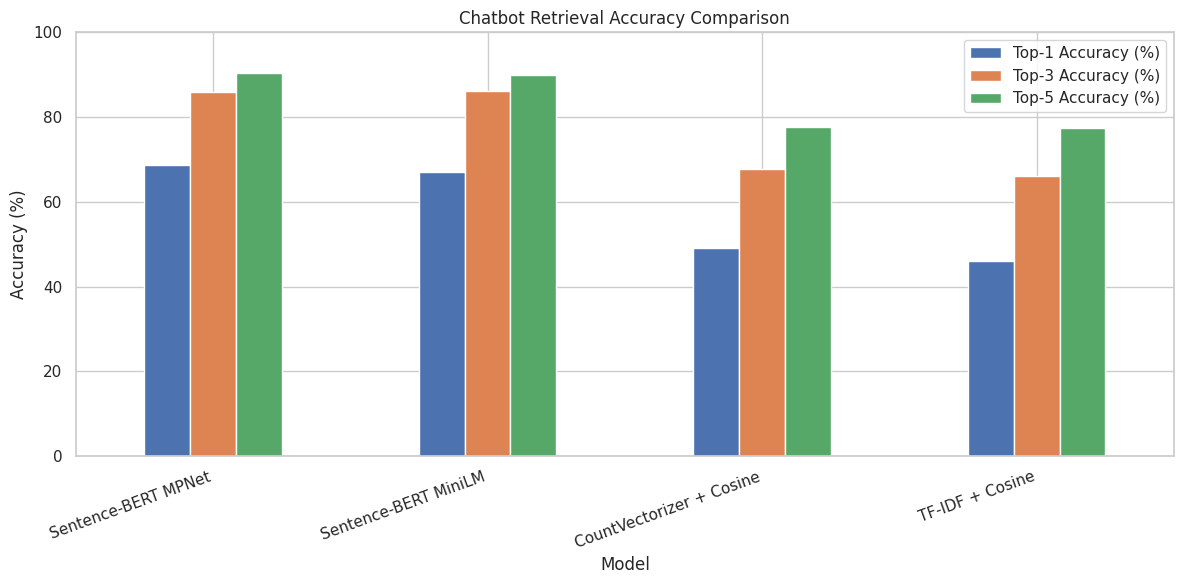

In [19]:
plot_df = comparison_df.set_index("Model")[
    ["Top-1 Accuracy (%)", "Top-3 Accuracy (%)", "Top-5 Accuracy (%)"]
]
plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Chatbot Retrieval Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "model_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 19. Response-time comparison graph

Lower response time is better. MiniLM is expected to offer a stronger deployment balance than the larger MPNet model.

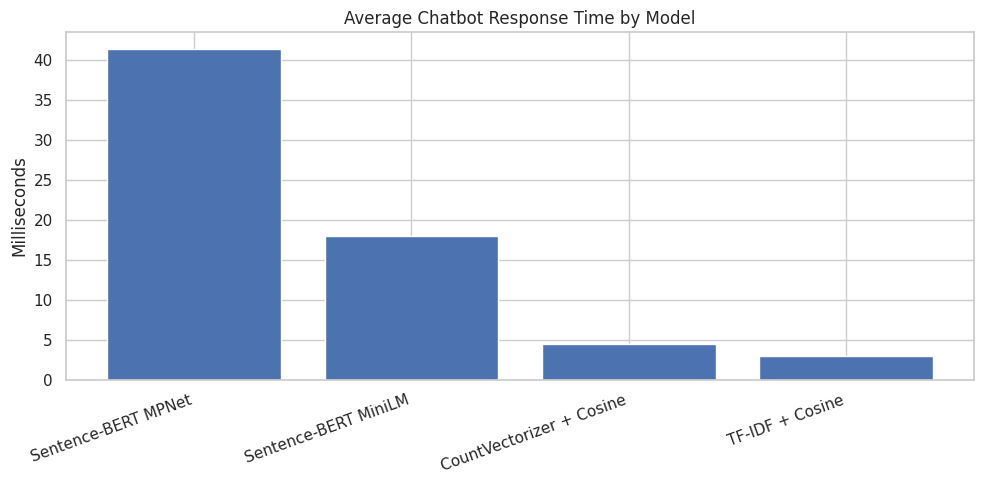

In [20]:
plt.figure(figsize=(10, 5))
plt.bar(comparison_df["Model"], comparison_df["Average Response Time (ms)"])
plt.title("Average Chatbot Response Time by Model")
plt.ylabel("Milliseconds")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "model_response_time_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Focus-area confusion matrix

## 20. Why this confusion matrix is valid

The chatbot is not a disease classifier. Its primary task is retrieving a matching question and answer.

For diagnostic analysis:

- Actual class = focus area of the user's source question.
- Predicted class = focus area of the rank-1 retrieved question.

This matrix therefore measures **topic retrieval**, not clinical diagnosis.

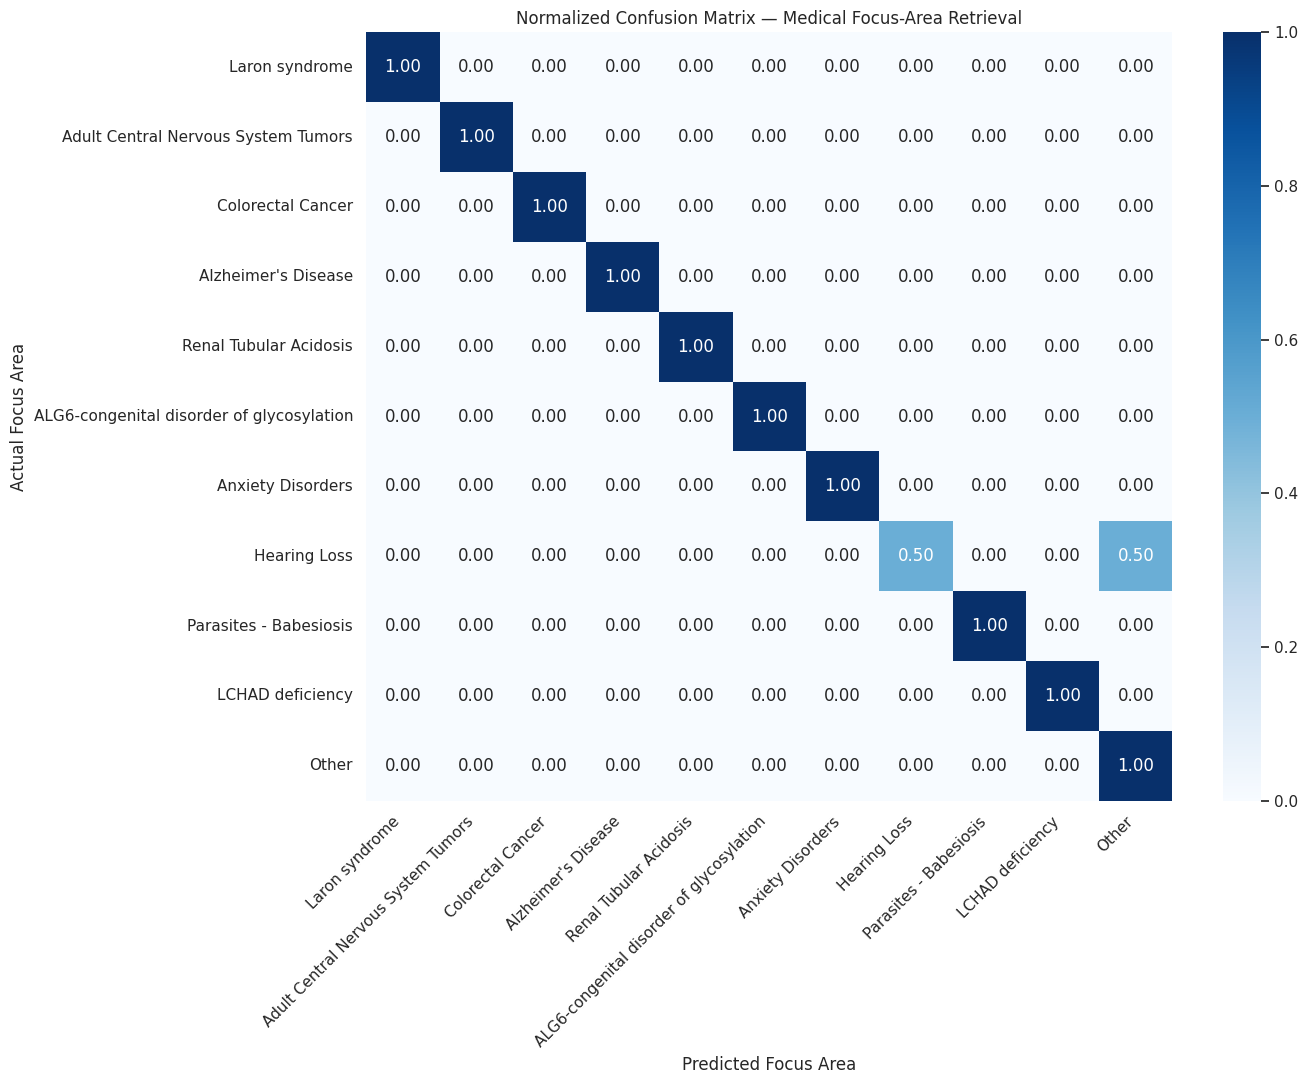

In [21]:
deployment_predictions = stored_predictions["Sentence-BERT MiniLM"][:, 0]
top_topics = sample_df["focus_area"].value_counts().head(10).index.tolist()

def group_topic(topic):
    return topic if topic in top_topics else "Other"

actual_topics = [group_topic(v) for v in sample_df["focus_area"]]
predicted_topics = [
    group_topic(df.iloc[int(i)]["focus_area"])
    for i in deployment_predictions
]
topic_labels = top_topics + ["Other"]

cm = confusion_matrix(
    actual_topics,
    predicted_topics,
    labels=topic_labels,
    normalize="true"
)

plt.figure(figsize=(14, 11))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=topic_labels,
    yticklabels=topic_labels
)
plt.title("Normalized Confusion Matrix — Medical Focus-Area Retrieval")
plt.xlabel("Predicted Focus Area")
plt.ylabel("Actual Focus Area")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "focus_area_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 21. Topic-level classification metrics

These metrics summarize whether the retrieved answer came from the correct medical topic.

In [22]:
topic_report = classification_report(
    actual_topics,
    predicted_topics,
    labels=topic_labels,
    output_dict=True,
    zero_division=0
)
topic_report_df = pd.DataFrame(topic_report).transpose()
display(topic_report_df)
topic_report_df.to_csv(OUTPUT_DIR / "focus_area_classification_report.csv")

topic_accuracy = accuracy_score(actual_topics, predicted_topics)
p, r, f1, _ = precision_recall_fscore_support(
    actual_topics, predicted_topics, average="weighted", zero_division=0
)
topic_metrics = pd.DataFrame({
    "Metric": ["Topic Accuracy", "Weighted Precision", "Weighted Recall", "Weighted F1"],
    "Score": [topic_accuracy, p, r, f1]
})
display(topic_metrics)

,precision,recall,f1-score,support
Laron syndrome,1.000000,1.000000,1.000000,3.000
Adult Central Nervous System Tumors,1.000000,1.000000,1.000000,3.000
Colorectal Cancer,1.000000,1.000000,1.000000,3.000
Alzheimer's Disease,1.000000,1.000000,1.000000,3.000
Renal Tubular Acidosis,1.000000,1.000000,1.000000,2.000
ALG6-congenital disorder of glycosylation,1.000000,1.000000,1.000000,2.000
Anxiety Disorders,1.000000,1.000000,1.000000,2.000
Hearing Loss,1.000000,0.500000,0.666667,2.000
Parasites - Babesiosis,1.000000,1.000000,1.000000,2.000
LCHAD deficiency,0.666667,1.000000,0.800000,2.000


,Metric,Score
0,Topic Accuracy,0.996000
1,Weighted Precision,0.996667
2,Weighted Recall,0.996000
3,Weighted F1,0.995867


# Confidence and threshold analysis

## 22. Similarity-score histogram

The similarity score indicates semantic closeness. It is **not** a medically calibrated probability.

The deployed threshold is `0.55`. Scores below it trigger the safe fallback response.

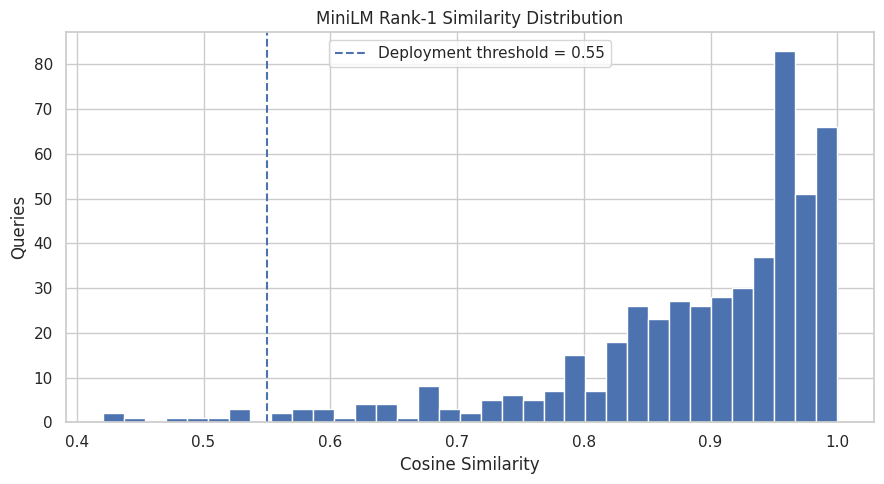

In [23]:
plt.figure(figsize=(9, 5))
plt.hist(minilm_top_scores, bins=35)
plt.axvline(0.55, linestyle="--", label="Deployment threshold = 0.55")
plt.title("MiniLM Rank-1 Similarity Distribution")
plt.xlabel("Cosine Similarity")
plt.ylabel("Queries")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "similarity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 23. Confidence-level pie chart

The categories explain how many test queries produce weak, moderate or strong semantic matches.

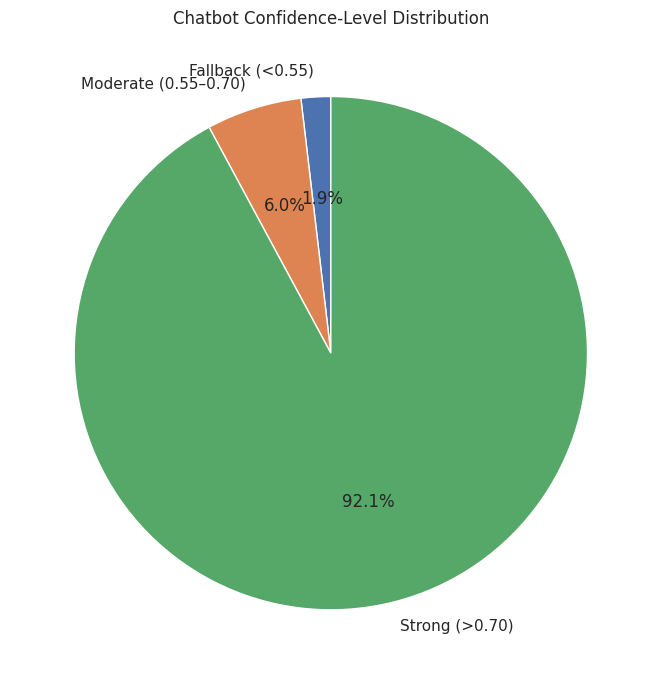

In [24]:
confidence_categories = pd.cut(
    minilm_top_scores,
    bins=[-1, 0.55, 0.70, 1.0],
    labels=["Fallback (<0.55)", "Moderate (0.55–0.70)", "Strong (>0.70)"]
)
confidence_counts = confidence_categories.value_counts().sort_index()

plt.figure(figsize=(8, 7))
plt.pie(
    confidence_counts.values,
    labels=confidence_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Chatbot Confidence-Level Distribution")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "confidence_level_pie.png", dpi=300, bbox_inches="tight")
plt.show()

## 24. Threshold accuracy and coverage

- Coverage = percentage of queries answered from MedQuAD.
- Accepted Top-1 accuracy = exact retrieval accuracy among accepted queries.

A higher threshold usually reduces coverage while improving trust in accepted matches.

,Threshold,Coverage,Accepted Top-1 Accuracy
0,0.35,1.000,0.670000
1,0.40,1.000,0.670000
2,0.45,0.994,0.674044
3,0.50,0.990,0.674747
4,0.55,0.982,0.680244
5,0.60,0.968,0.683884
6,0.65,0.952,0.684874
7,0.70,0.924,0.699134
8,0.75,0.900,0.700000
9,0.80,0.846,0.704492


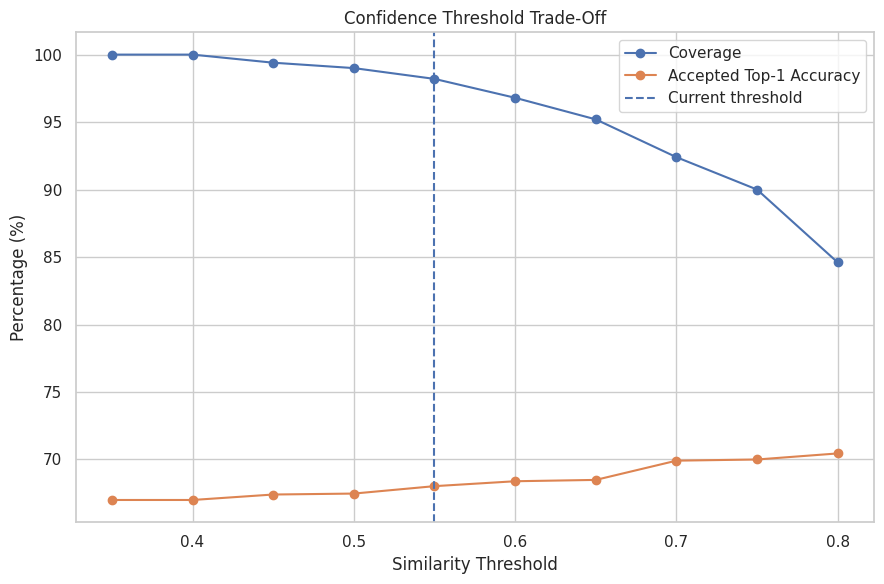

In [25]:
correct_top1 = (
    stored_predictions["Sentence-BERT MiniLM"][:, 0] ==
    sample_df["original_index"].to_numpy()
)

threshold_rows = []
for threshold in np.arange(0.35, 0.81, 0.05):
    accepted = minilm_top_scores >= threshold
    coverage = accepted.mean()
    accepted_accuracy = correct_top1[accepted].mean() if accepted.any() else np.nan
    threshold_rows.append({
        "Threshold": round(float(threshold), 2),
        "Coverage": coverage,
        "Accepted Top-1 Accuracy": accepted_accuracy
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)
threshold_df.to_csv(OUTPUT_DIR / "threshold_analysis.csv", index=False)

plt.figure(figsize=(9, 6))
plt.plot(threshold_df["Threshold"], threshold_df["Coverage"] * 100, marker="o", label="Coverage")
plt.plot(
    threshold_df["Threshold"],
    threshold_df["Accepted Top-1 Accuracy"] * 100,
    marker="o",
    label="Accepted Top-1 Accuracy"
)
plt.axvline(0.55, linestyle="--", label="Current threshold")
plt.title("Confidence Threshold Trade-Off")
plt.xlabel("Similarity Threshold")
plt.ylabel("Percentage (%)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "threshold_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

# Embedding visualization and error analysis

## 25. PCA graph of medical question embeddings

PCA reduces the 384-dimensional MiniLM vectors to two dimensions. Nearby points have similar semantic representations, although overlapping medical topics are expected.

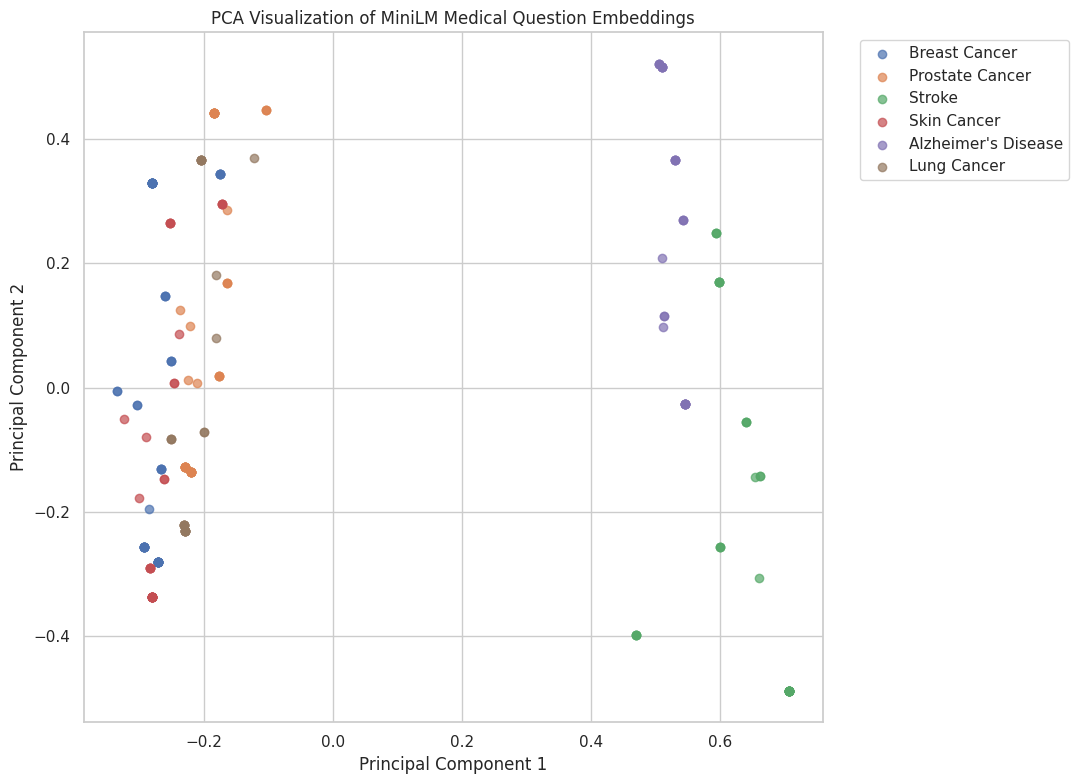

In [26]:
visual_topics = df["focus_area"].value_counts().head(6).index.tolist()
visual_df = pd.concat([
    df[df["focus_area"] == topic].sample(
        min(70, len(df[df["focus_area"] == topic])),
        random_state=SEED
    )
    for topic in visual_topics
]).copy()

visual_embeddings = minilm_model.encode(
    visual_df["question"].tolist(),
    convert_to_numpy=True,
    normalize_embeddings=True,
    batch_size=64
)

pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(visual_embeddings)
visual_df["PCA1"] = coords[:, 0]
visual_df["PCA2"] = coords[:, 1]

plt.figure(figsize=(11, 8))
for topic in visual_topics:
    part = visual_df[visual_df["focus_area"] == topic]
    plt.scatter(part["PCA1"], part["PCA2"], label=topic, alpha=0.7)
plt.title("PCA Visualization of MiniLM Medical Question Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "embedding_pca.png", dpi=300, bbox_inches="tight")
plt.show()

## 26. Error-analysis table

The table shows difficult paraphrased queries where the expected question was not ranked first. This helps explain errors during a defense.

In [27]:
error_rows = []
ranked = stored_predictions["Sentence-BERT MiniLM"]

for row_position, row in sample_df.iterrows():
    predicted_index = int(ranked[row_position, 0])
    correct_index = int(row["original_index"])
    if predicted_index != correct_index:
        error_rows.append({
            "User Query": row["user_query"],
            "Expected Question": df.iloc[correct_index]["question"],
            "Retrieved Question": df.iloc[predicted_index]["question"],
            "Actual Focus Area": df.iloc[correct_index]["focus_area"],
            "Retrieved Focus Area": df.iloc[predicted_index]["focus_area"],
            "Similarity": minilm_top_scores[row_position]
        })

errors_df = pd.DataFrame(error_rows).sort_values("Similarity", ascending=False)
display(errors_df.head(20))
errors_df.to_csv(OUTPUT_DIR / "chatbot_error_analysis.csv", index=False)

,User Query,Expected Question,Retrieved Question,Actual Focus Area,Retrieved Focus Area,Similarity
64,is isobutyryl-coa dehydrogenase deficiency inh...,Is isobutyryl-CoA dehydrogenase deficiency inh...,Is Isobutyryl-CoA dehydrogenase deficiency inh...,isobutyryl-CoA dehydrogenase deficiency,Isobutyryl-CoA dehydrogenase deficiency,1.000000
102,is hypokalemic periodic paralysis inherited ?,Is Hypokalemic periodic paralysis inherited ?,Is hypokalemic periodic paralysis inherited ?,Hypokalemic periodic paralysis,hypokalemic periodic paralysis,1.000000
16,what to do for hypothyroidism ?,What to do for Hypothyroidism ?,What to do for Hypothyroidism ?,Hypothyroidism,Hypothyroidism,1.000000
14,is holt-oram syndrome inherited ?,Is Holt-Oram syndrome inherited ?,Is Holt-Oram syndrome inherited ?,Holt-Oram syndrome,Holt-Oram syndrome,1.000000
2,how to prevent balance problems ?,How to prevent Balance Problems ?,How to prevent Balance Problems ?,Balance Problems,Balance Problems,1.000000
58,how to diagnose primary hyperparathyroidism ?,How to diagnose Primary Hyperparathyroidism ?,How to diagnose Primary Hyperparathyroidism ?,Primary Hyperparathyroidism,Primary Hyperparathyroidism,1.000000
106,how to prevent copd ?,How to prevent COPD ?,How to prevent COPD ?,COPD,COPD,1.000000
7,is fragile x syndrome inherited ?,Is Fragile X syndrome inherited ?,Is fragile X syndrome inherited ?,Fragile X syndrome,fragile X syndrome,1.000000
108,explain (are) fibrodysplasia ossificans progre...,What is (are) Fibrodysplasia ossificans progre...,What is (are) fibrodysplasia ossificans progre...,Fibrodysplasia ossificans progressiva,fibrodysplasia ossificans progressiva,0.977948
86,explain (are) pallister-killian mosaic syndrome ?,What is (are) Pallister-Killian mosaic syndrome ?,What is (are) Pallister-Killian mosaic syndrome ?,Pallister-Killian mosaic syndrome,Pallister-Killian mosaic syndrome,0.973971


## 27. Generate `medquad_embeddings.npy`

In [28]:
DEPLOYMENT_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
deployment_model = SentenceTransformer(DEPLOYMENT_MODEL_NAME, device=DEVICE)

deployment_embeddings = deployment_model.encode(
    df["question"].astype(str).tolist(),
    convert_to_numpy=True,
    normalize_embeddings=True,
    batch_size=64,
    show_progress_bar=True
).astype("float32")

EMBEDDINGS_PATH = OUTPUT_DIR / "medquad_embeddings.npy"
np.save(EMBEDDINGS_PATH, deployment_embeddings)

print("Saved:", EMBEDDINGS_PATH)
print("Embedding shape:", deployment_embeddings.shape)
print("Expected rows:", len(df))
assert len(deployment_embeddings) == len(df)
assert deployment_embeddings.shape[1] == 384

Batches:   0%|          | 0/257 [00:00<?, ?it/s]

Saved: /content/izi_chatbot_outputs/medquad_embeddings.npy
Embedding shape: (16407, 384)
Expected rows: 16407


## 28. Save model information and final accuracy results

In [29]:
deployment_row = comparison_df[
    comparison_df["Model"] == "Sentence-BERT MiniLM"
].iloc[0]

model_info = {
    "project": "IZI Health Chatbot",
    "deployment_model": DEPLOYMENT_MODEL_NAME,
    "embedding_source_column": "question",
    "embedding_dimension": int(deployment_embeddings.shape[1]),
    "normalization": True,
    "similarity_method": "dot product of normalized vectors (cosine similarity)",
    "confidence_threshold": 0.55,
    "valid_dataset_rows": int(len(df)),
    "top1_accuracy_percent": float(deployment_row["Top-1 Accuracy (%)"]),
    "top3_accuracy_percent": float(deployment_row["Top-3 Accuracy (%)"]),
    "top5_accuracy_percent": float(deployment_row["Top-5 Accuracy (%)"]),
    "mrr": float(deployment_row["MRR"]),
    "average_response_time_ms": float(deployment_row["Average Response Time (ms)"])
}

with open(OUTPUT_DIR / "chatbot_model_information.json", "w") as f:
    json.dump(model_info, f, indent=4)

print(json.dumps(model_info, indent=2))

{
  "project": "IZI Health Chatbot",
  "deployment_model": "sentence-transformers/all-MiniLM-L6-v2",
  "embedding_source_column": "question",
  "embedding_dimension": 384,
  "normalization": true,
  "similarity_method": "dot product of normalized vectors (cosine similarity)",
  "confidence_threshold": 0.55,
  "valid_dataset_rows": 16407,
  "top1_accuracy_percent": 67.0,
  "top3_accuracy_percent": 86.2,
  "top5_accuracy_percent": 90.0,
  "mrr": 0.7666,
  "average_response_time_ms": 17.958385987999126
}


## 29. Verify retrieval using the exported file

In [30]:
reloaded_embeddings = np.load(EMBEDDINGS_PATH)

def deployment_retrieve(question, threshold=0.55):
    query_embedding = deployment_model.encode(
        [question],
        convert_to_numpy=True,
        normalize_embeddings=True
    )[0]
    similarities = np.dot(reloaded_embeddings, query_embedding)
    best_index = int(np.argmax(similarities))
    confidence = float(similarities[best_index])
    row = df.iloc[best_index]

    return {
        "question": question,
        "matchedQuestion": row["question"],
        "answer": row["answer"] if confidence >= threshold else "Safe fallback should be used.",
        "confidence": confidence,
        "source": row["source"],
        "focus_area": row["focus_area"],
        "mode": "medquad_semantic" if confidence >= threshold else "safe_fallback"
    }

display(pd.DataFrame([
    deployment_retrieve("What are the symptoms of diabetes?"),
    deployment_retrieve("How is glaucoma treated?")
]))

,question,matchedQuestion,answer,confidence,source,focus_area,mode
0,What are the symptoms of diabetes?,What are the symptoms of Diabetes ?,"Diabetes is often called a ""silent"" disease be...",1.000000,NIHSeniorHealth,Diabetes,medquad_semantic
1,How is glaucoma treated?,What are the treatments for Glaucoma ?,"Although open-angle glaucoma cannot be cured, ...",0.890778,NIHSeniorHealth,Glaucoma,medquad_semantic


## 30. Package and download the chatbot outputs

In [31]:
PACKAGE_BASE = "/content/IZI_Health_Chatbot_Colab_Outputs"
shutil.make_archive(PACKAGE_BASE, "zip", root_dir=OUTPUT_DIR)
files.download(PACKAGE_BASE + ".zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>